# Multimodal Analysis of PCC-mPFC Connectivity, Symptom Severity, and DRD4 Expression in ADHD

## Team Name: Patch Clamp Champs
- Enrique Aranda | A17484190   :
- Brandon Melendez-Rodriguez | A17433726 :

## Abstract

### Overview

This project investigates the Default Mode Network (DMN) to understand how its resting-state functional connectivity differs between ADHD and control participants. We will analyze the communication between two core DMN areas, the posterior cingulate cortex (PCC) and medial prefrontal cortex (mPFC), and test how these network differences relate to clinical symptom severity. We extracted resting-state fMRI and phenotypic data from the ADHD-200 Preprocessed dataset, and mapped regional DRD4 gene expression from the Allen Human Brain Atlas onto these DMN hubs as a molecular reference. This approach is important because it allows us to decode DMN dysfunction across three distinct levels: network connectivity, human behavior, and localized dopamine receptor expression.


### Research Question

How does resting state functional connectivity of the Default Mode Network, specifically between the Posterior Cingulate Cortex and Medial Prefrontal Cortex, differ between ADHD and control participants, how is this connectivity related to DSM-based symptom severity, and how can regional DRD4 expression interpret these differences?

## Introduction & Background

### Prior Work

ADHD is a neurodevelopmental disorder that is associated with inattention, impulsivity, and hyperactivity, and research suggests that these symptoms are linked to altered communication across large scale brain networks rather than dysfunction in a single brain region. *De La Fuente et al.* describes ADHD as involving structural and functional abnormalities in multiple neural systems, specifically networks related to attention, executive function, and resting state processing. One network that has been repeatedly implicated is the Default Mode Network (DMN), which includes the posterior cingulate cortex (PCC) and medial prefrontal cortex (mPFC). The DMN is highly active during internal thought and daydreaming, but must be suppressed to maintain focus on external tasks. In ADHD, the DMN fails to be suppressed which is then thought to drive lapses in attention. To study this, we focus on the posterior cingulate cortex (PCC) and medial prefrontal cortex (mPFC), as these two regions serve as the major structural and functional anchors of the DMN.

In addition to altered brain network organization, dopamine related signaling has also been widely implicated in ADHD. *Volkow et al.* explains that dopamine genes, including DRD4, are part of the broader dopamine hypothesis of ADHD and are relevant to understanding reward, motivation, and attention related symptoms. DRD4 provides a molecular context for interpreting connectivity differences observed in the imaging data. Together, prior work supports a multimodal approach that combines the lack of brain connectivity in ADHD, clinical symptoms, and dopamine related gene expression context to better understand the Default Mode Netwok.

### Dataset

This project uses two public data sources to integrate three modalities. The first is the ADHD-200 Preprocessed dataset, which contains resting state fMRI data and phenotype data from children and adolescents with ADHD and control participants. We will be using the resting state fMRI data to measure functional connectivity between the posterior cingulate cortex (PCC) and medial prefrontal cortex (mPFC), and we use the phenotype data to measure DSM-based symptom severity. THe ADHD-200 Consoritum highlights that this dataset is valuable because it combines imaging and phenotypic information in a large shared resource, making it possible to connect neural differences to behavioral measures.

The second source is the Allen Human Brain Atlas, which contains regional gene expression measurements across the human brain (Allen Insitute for Brain Science). From this dataset, we extract regional DRD4 expression near the PCC and mPFC coordinates used in the connectivity analysis. This gives us the third modality for the project, molecular context. Together, these datasets allow us to study resting state functional connectivity, symptom severity, and regional gene expression information in the same project. This multimodal design is important because it moves beyond asking whether ADHD and control groups differ in connectivity alone and instead asks how those differences relate to both behavior and dopamine related molecular context.

### Hypothesis

We hypothesize that ADHD participants will show altered resting state functional connectivity between the posterior cingulate cortex (PCC) and medial prefrontal cortex (mPFC) compared with control participants. We further predict that more weaker PCC-mPFC connectivity will be associated with greater DSM based symptom severity. Finally, we expect that both PCC and mPFC will show measurable regional DRD4 expression, allowing dopamine related molecular context to help interpret any observed connectivity differences. Overall, we hope to paint a clearer picture of the Default Mode Network of the human brain by integrating network-level connectivity issues, inattentive and hyperactive behavior, and local gene expression.  

## Data Analysis

### Data Wrangling

In [114]:
# install if you dont have this
!pip install nilearn
# !pip install seaborn
# !pip install scipy

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import ttest_ind, pearsonr

#ADHD-200 Preprocessed Dataset
from nilearn import datasets
from nilearn.maskers import NiftiSpheresMasker
from nilearn import plotting

In [115]:
# Fetch ADHD-200 Dataset and save it to adhd_data
# https://nilearn.github.io/dev/modules/generated/nilearn.datasets.fetch_adhd.html

adhd_data = datasets.fetch_adhd(n_subjects=40)

# Internet-Assisted
# MNI coordinates are standardized coordinates for 3D neuroimaging
# the MNI coordinates for PCC is 0, -53, 26 and for mPFC is 0, 51, -6

pcc_coords  = (0, -53, 26)   # Posterior Cingulate Cortex
mpfc_coords = (0,  51,  -6)  # Medial Prefrontal Cortex


[fetch_adhd] Dataset found in /root/nilearn_data/adhd

fMRI Data: We fetched 40 subjects from the ADHD-200 Athena-preprocessed dataset.

In [116]:
# Download Allen Human Brian Atlas Dataset
# https://human.brain-map.org/api/v2/well_known_file_download/178238387

# metadata for human brain atlas data
probes_df = pd.read_csv('Probes.csv')
samples_df = pd.read_csv('SampleAnnot.csv')
samples_df.head()

,structure_id,slab_num,well_id,slab_type,structure_acronym,structure_name,polygon_id,mri_voxel_x,mri_voxel_y,mri_voxel_z,mni_x,mni_y,mni_z
0,4077,22,594,CX,PCLa-i,"paracentral lobule, anterior part, right, infe...",37470,87,52,116,5.9,-27.7,49.7
1,4323,11,2985,CX,Cl,"claustrum, right",40517,66,92,63,29.2,17.0,-2.9
2,4323,18,2801,CX,Cl,"claustrum, right",41516,66,81,104,28.2,-22.8,16.8
3,4440,18,2273,CX,LGd,"dorsal lateral geniculate nucleus, left",41473,116,94,101,-24.6,-24.6,1.3
4,4266,17,2785,CX,CA4,"CA4 field, right",41142,63,104,106,31.1,-31.3,-7.3


In [117]:
# Phenotype dataset is part of the adhd_200 dataset that includes phenotypic data of the patients
pheno_df = pd.DataFrame(adhd_data.phenotypic)
# assigns subject as adhd or control
pheno_df['Group'] = pheno_df['adhd'].apply(
    lambda x: 'Control' if str(x).strip() == '0' else 'ADHD'
)

pheno_df.columns
pheno_df['dsm_iv_h_i'].value_counts()
pheno_df['dsm_iv_inatt'].value_counts()
pheno_df['dsm_iv_tot'].value_counts()

pheno_df['calculated_symptom_score'] = pheno_df['dsm_iv_tot'].fillna(
    pheno_df[['dsm_iv_inatt', 'dsm_iv_h_i']].sum(axis=1, min_count=1)
)


The ADHD-200 dataset contains a dataset of the patients' phenotypic data through its phenotypic function which is how we get pheno_df. We have a calculated symptom score since the phenotype dataset splits up the symptom severity in three columns: based on total symptoms, hyperactivity, and inattentive.

In [118]:
# Gemini-Assisted method, helps look at the brain at a specific area using the MNI coordinates
masker = NiftiSpheresMasker(
    seeds=[pcc_coords, mpfc_coords],
    radius=8.0,
    standardize='zscore_sample',
    detrend=True,
    low_pass=0.1,
    high_pass=0.01,
    t_r=2.0
)

connectivity_records = []
for i in range( len(pheno_df)):
    func_file  = adhd_data.func[i]
    row        = pheno_df.iloc[i]

    # Extract time-series
    time_series  = masker.fit_transform(func_file)
    pcc_signal   = time_series[:, 0]
    mpfc_signal  = time_series[:, 1]

    # Pearson r then Fisher Z-transform for normality
    r_val, _ = pearsonr(pcc_signal, mpfc_signal)
    z_val    = np.arctanh(np.clip(r_val, -0.999, 0.999))

    symptom_score = row.get('calculated_symptom_score', np.nan)
    connectivity_records.append({
        'Subject':        row['Subject'],
        'Group':          row['Group'],
        'Symptom_Score':  symptom_score,
        'Connectivity_Z': z_val
    })

results_df    = pd.DataFrame(connectivity_records)
results_df['Symptom_Score'] = pd.to_numeric(results_df['Symptom_Score'], errors='coerce')
results_clean = results_df.dropna(subset=['Symptom_Score'])

print(results_df['Group'].value_counts())

Group
Control    17
ADHD       13
Name: count, dtype: int64


We extract the Blood-Oxygen-Level Dependent fMRI time-series data from our two regions of interest (the PCC and mPFC) and computed the functional connectivity between them using a Pearson correlation. After aligning this brain data with our clinical phenotypes and dropping any subjects who were missing their symptom scores, the output confirms our final analytical sample consists of exactly 30 viable subjects: 17 healthy controls and 13 patients with ADHD.

### Data Visualization

Control Subject Count:  17
ADHD Subject Count:  13


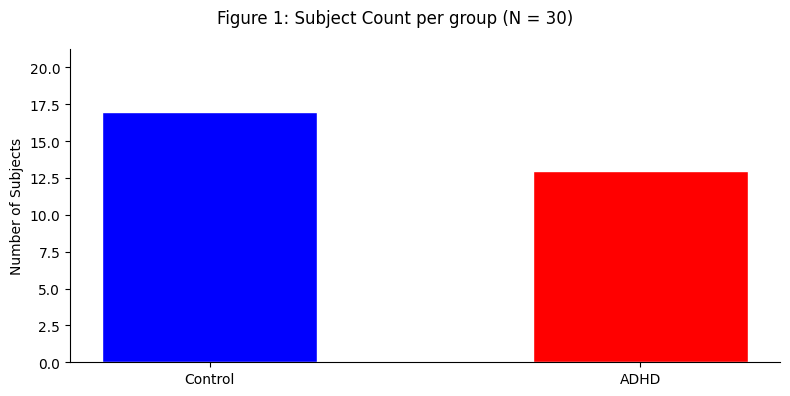

In [119]:
# Figure 1
# Visualization of the Groups of our dataset
group_counts = results_df['Group'].value_counts()

fig, ax = plt.subplots(figsize=(8, 4))

colors = ['red' if g == 'ADHD' else 'blue' for g in group_counts.index]
ax.bar(group_counts.index, group_counts.values, color=colors, width=0.5, edgecolor='white')


ax.set_ylabel('Number of Subjects')
ax.set_ylim(0, group_counts.max() * 1.25)
sns.despine()


fig.suptitle(f'Figure 1: Subject Count per group (N = {len(results_df)})')

print(f'Control Subject Count: ',len(results_df[results_df['Group'] == 'Control']))
print(f'ADHD Subject Count: ',len(results_df[results_df['Group'] == 'ADHD']))

plt.tight_layout()
plt.show()


Out of the 40 subjects that we get from the fetch_adhd method, several were missing clinical phenotypic data. We utilized results_df.dropna() to remove subjects without symptom scores, resulting in a final analytical sample of N=30.

    Subject    Group  Symptom_Score  Connectivity_Z
0   2014113     ADHD            NaN        1.316860
1   3902469  Control            NaN        1.485258
2   4275075     ADHD            NaN        1.230879
3   7774305  Control            NaN        0.722609
4   1019436     ADHD            NaN        1.543384
5   3699991  Control            NaN        1.111880
6   3154996     ADHD            NaN        0.892839
7   3884955  Control            NaN        0.718337
8   4134561  Control            NaN        0.493243
9   6115230  Control            NaN        0.631762
10  8409791  Control            NaN        0.533243
11  3007585  Control            NaN        0.998049
12  8697774     ADHD           74.0        0.938785
13  9750701  Control           40.0        0.696159
14  2497695     ADHD           82.0        1.330277
15  4164316  Control           41.0        0.689849
16  1552181     ADHD            NaN        0.568945
17  4046678  Control            NaN        0.955941
18  1679142 

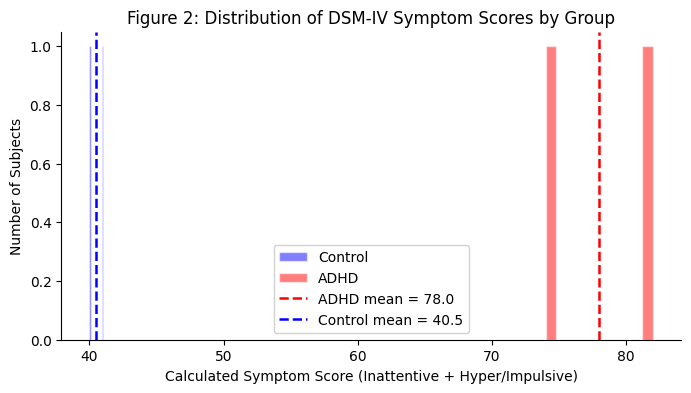

In [120]:
# Figure 2

# Visualizing the distribution of symptom scores, should be higher for ADHD, as they exhibit more symptoms
fig, ax = plt.subplots(figsize=(8, 4))
adhd_scores = results_clean[results_clean['Group'] == 'ADHD']['Symptom_Score']
ctrl_scores = results_clean[results_clean['Group'] == 'Control']['Symptom_Score']

ax.hist(ctrl_scores, alpha=0.5, color='blue', label='Control', edgecolor='white')
# transparency to show it's behind the mean.
ax.hist(adhd_scores, alpha=0.5, color='red', label='ADHD',    edgecolor='white')

# Internet-assisted to add mean lines on a histogram.
ax.axvline(adhd_scores.mean(), color='red', linestyle='--', linewidth=1.8,
           label=f'ADHD mean = {adhd_scores.mean():.1f}')
ax.axvline(ctrl_scores.mean(), color='blue', linestyle='--', linewidth=1.8,
           label=f'Control mean = {ctrl_scores.mean():.1f}')
print(results_df)
ax.set_xlabel('Calculated Symptom Score (Inattentive + Hyper/Impulsive)')
ax.set_ylabel('Number of Subjects')
ax.set_title('Figure 2: Distribution of DSM-IV Symptom Scores by Group')
ax.legend(framealpha=0.9)
sns.despine()
plt.show()


 Here, we made a histogram to visualize the distribution of calculated DSM-IV symptom scores across the two groups. By plotting the frequency of scores alongside the mean for each group, we can show that the subjects marked as having ADHD in the dataset, do indeed have higher amount of symptoms based on our calculated symptom score. However, this is when we notice that out of the thirty subjects that had phenotypic data, only four subjects had marked symptoms on the dataset. This sets an unfortunate precedent on our report as we hoped to link ADHD behavior with functional connectivity of the brain using the ADHD-200 dataset.

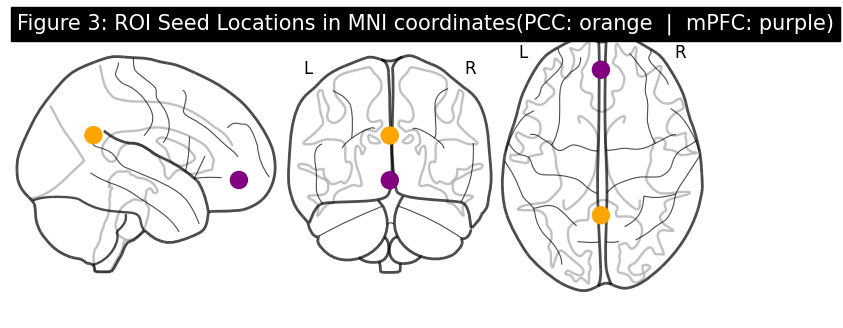

In [128]:
# Figure 3
# Gemini-Assisted, needed help using nilearn to mark the specific regions of interest, the pcc and the mpfc

node_coords_roi = [(0, -53, 26), (0, 51, -6)]
node_colors_roi = ['orange', 'purple']   # orange = PCC, purple = mPFC

# Zero adjacency matrix — we are showing node locations only, no edges
adj_zero = np.array([[0, 0], [0, 0]], dtype=float)

fig, ax = plt.subplots(figsize=(9, 4))
plotting.plot_connectome(
    adj_zero,
    node_coords_roi,
    node_color=node_colors_roi,
    node_size=150,
    title='Figure 3: ROI Seed Locations in MNI coordinates'
          '(PCC: orange  |  mPFC: purple)',
    axes=ax,
    colorbar=False
)
plt.show()


We marked the microarray tissue samples within a 15mm Euclidean distance of the fMRI coordinates that contained the DRD4 gene using the plotting package from nilearn.

### Data Analysis & Results

#### Setup

In [129]:
adhd_fc = results_df[results_df['Group'] == 'ADHD']['Connectivity_Z']
ctrl_fc = results_df[results_df['Group'] == 'Control']['Connectivity_Z']
t_stat, p_val_ttest = ttest_ind(adhd_fc, ctrl_fc, equal_var=False)


print(f'Processed {len(results_df)} subjects.')
print(f'T-Test (ADHD vs Control): t = {t_stat:.2f}, p = {p_val_ttest:.2f}')


Processed 30 subjects.
T-Test (ADHD vs Control): t = 1.11, p = 0.28


The T-test is done to show differences between the funcitonal connectivity of ADHD patients vs Control patients. Since the p-value is greater than 0.05, the difference between the two groups is not statistically significant. Therefore, our data does not prove that the PCC and mPFC are more disconnected in the ADHD group vs the Control group.




/tmp/ipykernel_848/283218482.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Group', y='Connectivity_Z', data=results_df, palette=['red', 'blue'])


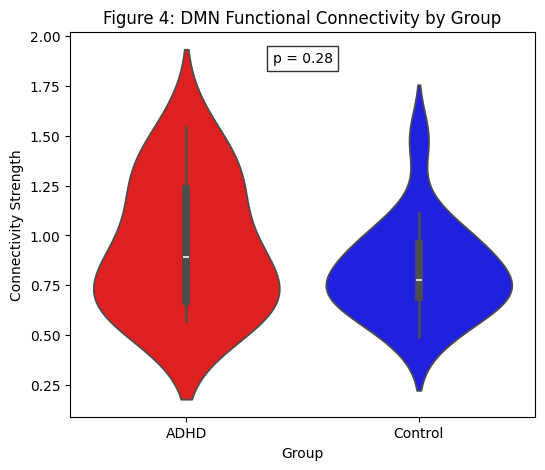

In [130]:
# Figure 4
# Violin Plot showing functional connectivity
plt.figure(figsize=(6, 5))
sns.violinplot(x='Group', y='Connectivity_Z', data=results_df, palette=['red', 'blue'])

plt.title('Figure 4: DMN Functional Connectivity by Group')
plt.ylabel('Connectivity Strength')
plt.text(0.5, 0.92, f'p = {p_val_ttest:.2f}',
         ha='center', transform=plt.gca().transAxes,
         bbox=dict(facecolor='white', alpha=0.8))

plt.show()

This is a visualization of the t-test comparing the functional connectivities of the ADHD group and Control group. The violin plot shows us the density of the data with the width of the violin and shows us the spread of the data along the y-axis, which in this case is connectivity strength. Here we see more variety for the ADHD group as their strength varies from very strong to very weak with a spread out distribution. On the other hand, the Control group seems to normalize around average connectivity strength of 0.75 with hardly any diversity. Since the p-value is 0.28, which is over 0.05, the results are not statistically significant and the data does not prove there is a difference in functional connectivity.

In [131]:
# Calculating correlation between functionl connectivity of Default Mode Network and severity of Symptoms
r_stat, p_val_corr = pearsonr(results_clean['Connectivity_Z'], results_clean['Symptom_Score'])
print(f'Correlation (Functional Connectivity vs Symptoms): r = {r_stat:.2f}, p = {p_val_corr:.2f}')

Correlation (Functional Connectivity vs Symptoms): r = 0.92, p = 0.08


In addition, we measured the correlation between the functional connectivity of the Default Mode Network and the severity of the symptoms in patients, and we see a positive trend with a pearson's r-value of 0.92. Our p-value is slightly above 0.05 at 0.08, so our results are just trending towards statistical significance.

    Subject    Group  Symptom_Score  Connectivity_Z
0   2014113     ADHD            NaN        1.316860
1   3902469  Control            NaN        1.485258
2   4275075     ADHD            NaN        1.230879
3   7774305  Control            NaN        0.722609
4   1019436     ADHD            NaN        1.543384
5   3699991  Control            NaN        1.111880
6   3154996     ADHD            NaN        0.892839
7   3884955  Control            NaN        0.718337
8   4134561  Control            NaN        0.493243
9   6115230  Control            NaN        0.631762
10  8409791  Control            NaN        0.533243
11  3007585  Control            NaN        0.998049
12  8697774     ADHD           74.0        0.938785
13  9750701  Control           40.0        0.696159
14  2497695     ADHD           82.0        1.330277
15  4164316  Control           41.0        0.689849
16  1552181     ADHD            NaN        0.568945
17  4046678  Control            NaN        0.955941
18  1679142 

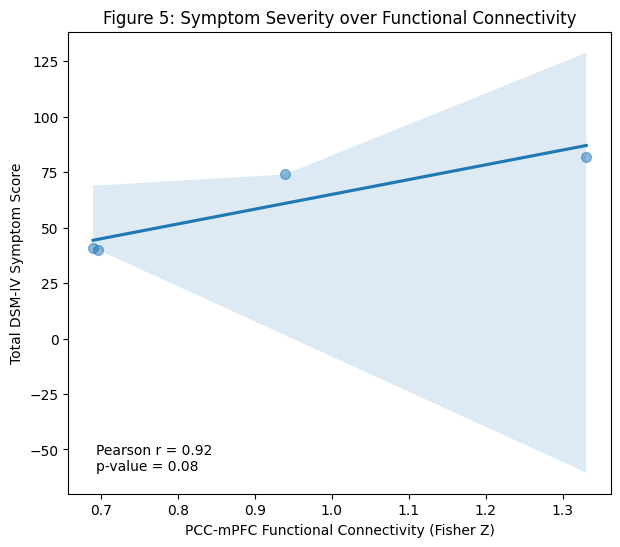

In [132]:
# Figure 5
plt.figure(figsize=(7, 6))
print(results_df)

sns.regplot(x='Connectivity_Z', y='Symptom_Score', data=results_df,
            scatter_kws={'alpha':0.5, 's':50})

plt.title('Figure 5: Symptom Severity over Functional Connectivity')
plt.xlabel('PCC-mPFC Functional Connectivity (Fisher Z)')
plt.ylabel('Total DSM-IV Symptom Score')
plt.text(0.05, 0.05, f'Pearson r = {r_stat:.2f}\np-value = {p_val_corr:.2f}',
          transform=plt.gca().transAxes,
)
print(len(results_df))
plt.show()

Figure 5 demonstrates the trend in ADHD symptom severity as functional connectivity between the PCC and mPFC increases. However, this figure contradicts our hypothesis that a functional disconnection between the PCC and mPFC would predict greater clinical symptom severity. The linear regression plot shows a strong positive trend (r = 0.92, p = 0.08), suggesting that with higher functional connectivity, there's a higher severity in ADHD symptoms. If we had more subjects with data on their ADHD symptoms, we should expect to see a line with a negative slope.

/tmp/ipykernel_848/2475301000.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Region', y='DRD4_Expression', data=drd4_all_samples,


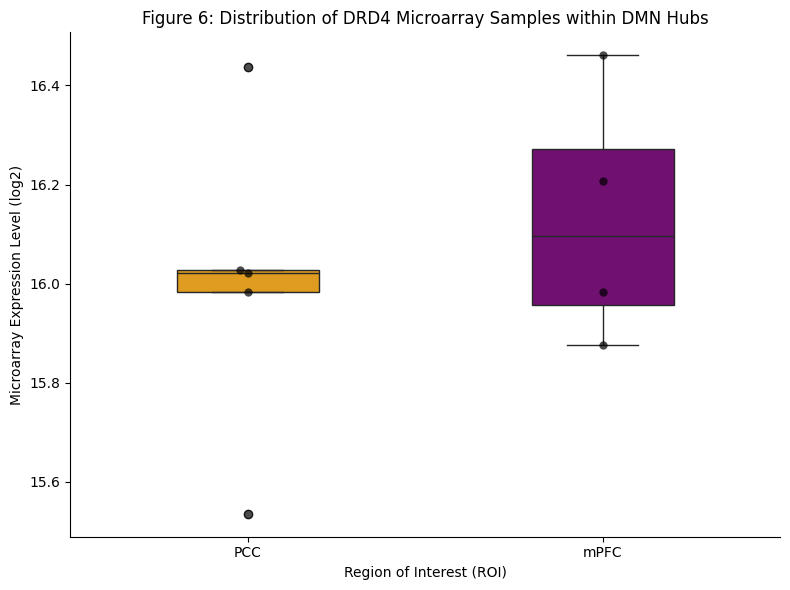

In [133]:
# Figure 6
# Gemini-Assisted function to visualize the gene expression levels of DRD4 within the PCC and mPFCx

# A modified function to return ALL samples, not just the mean
def get_expression_samples_within_radius(target_mni, samples_df, expression_values, radius_mm=15, region_name="ROI"):
    sample_coords = samples_df[['mni_x', 'mni_y', 'mni_z']].values
    distances = np.linalg.norm(sample_coords - np.array(target_mni), axis=1)
    mask = distances <= radius_mm

    # Get the raw expression values for all samples inside the radius
    nearby_expression = expression_values[mask]

    # Return a DataFrame so we can easily plot it
    return pd.DataFrame({
        'Region': [region_name] * len(nearby_expression),
        'DRD4_Expression': nearby_expression
    })

# Extracts individual tissue samples
pcc_samples = get_expression_samples_within_radius(pcc_coords, samples_df, drd4_expression_values, radius_mm=15, region_name='PCC')
mpfc_samples = get_expression_samples_within_radius(mpfc_coords, samples_df, drd4_expression_values, radius_mm=15, region_name='mPFC')
drd4_all_samples = pd.concat([pcc_samples, mpfc_samples])

fig, ax = plt.subplots(figsize=(8, 6))

# The boxplot shows the median and quartiles (
sns.boxplot(x='Region', y='DRD4_Expression', data=drd4_all_samples,
            palette=['orange', 'purple'], ax=ax, width=0.4, showfliers=True)

# The swarmplot overlays the actual individual brain tissue samples as dots
sns.swarmplot(x='Region', y='DRD4_Expression', data=drd4_all_samples,
              color='black', alpha=0.7, size=6, ax=ax)

plt.title('Figure 6: Distribution of DRD4 Microarray Samples within DMN Hubs')
plt.ylabel('Microarray Expression Level (log2)')
plt.xlabel('Region of Interest (ROI)')
sns.despine()
plt.tight_layout()
plt.show()

The box plot was generated using a 15mm Euclidean distance radius to extract all available DRD4 tissue samples surrounding our regions of interest which demonstrate the statistical distribution of samples. The density of dopamine receptor expression are shown based on the swarm plot. We see that there's higher distributon of expression level in mPFC than in PCC, and this could potentially be explained by the fact that mPFC requires dopamine to function optimally for cognitive processes.

## Conclusion & Discussion

### Results

This project examines whether resting state functional connectivity between the posterior cingulate cortex (PCC) and medial prefrontal cortex (mPFC) differed between ADHD and control participants. Whether this connectivity was related to DSM based symptom severity, and whether regional DRD4 expression could provide molecular context for these differences. In our analysis, the ADHD and control groups did not show a statistically significant difference in PCC-mPFC connectivity. The independent samples t test was t = 1.11 and p =0.28. This indicates that our data does not provide strong statistical evidence that the ADHD group is more disconnected than the control group in the PCC-mPFC connection. THis pattern is also shown in the violin plot which demonstrates an overlap between the two groups despite a slightly bigger spread in the ADHD distribution. 

We also tested whether connectivity was related to symptom severity. The correlation analysis did show a strong positive trend between the PCC-mPFC connectivity and DSM-based symptom score. With a Pearson's r = 0.92, but the result was not statistically significant because the p-value was 0.08, which is above the 0.05 threshold. This does suggest that there may be a relationship between connectivity and symptoms in the available sample, but the result should be interpreted cautiously due to a small number of complete symptom data. As shown in the printed table, most of the participants had missing symptom values, and only a handful contributed to the brain behavior correlation. 

Finally, the DRD4 analysis 

### Limitations

A major limitation of this project was the size and completeness of the available dataset. The ADHD subset we worked with was smaller than expected, and only a limited number of participants had complete imaging and phenotype information available. This reduced the strength of the statistical comparisons and made it difficult to draw strong conclusions. Exploratory visualizations were therefore especially useful for identifying patterns in the data and understanding which analyses were supported by the sample. Another challenge involved the Allen Human Brain Atlas dataset. Although it provided valuable regional gene expression information, it was technically difficult to work with, and importing the data into Python required substantial troubleshooting.

### Future Work

Future work could strengthen this project in several ways. Using a larger sample with more complete imaging and phenotype data would improve statistical power and make the brain behavior analysis more reliable. Second, fully resolving the Allen Human Brain Atlas import and processing issues would allow the DRD4 component to be more fully integrated into the final analysis. Third, future studies could expand beyond PCC–mPFC connectivity and examine other Default Mode Network regions or use a whole-brain connectivity approach to provide a broader picture of ADHD related network differences. It would also be valuable to incorporate structural MRI or other complementary modalities so that functional, behavioral, and molecular findings could be compared more directly.

## Reflection

One of the biggest challenges was working with incomplete and unevenly structured data, especially because the available ADHD sample was smaller than expected and only a limited number of participants had complete information for all parts of the analysis. This project was especially interesting because it gave us the opportunity to learn more about ADHD and to better understand how it relates to neuroscience through brain networks, behavior, and dopamine-related biology. Overall, this project gave us a better understanding of both the potential and the practical difficulties of multimodal neuroscience data analysis.

## Contributions

| Tasks | Enrique Aranda | Brandon Melendez-Rodriguez |
|---|---|---|
| Ensure that everyone is completing their tasks | ✓ | ✓ |
| Identify research papers & question | ✓ | ✓ |
| Write background section |  | ✓ |
| Write code to wrangle datasets | ✓ | ✓ |
| Write code to analyze/integrate datasets | ✓ |  |
| Write code to visualize findings | ✓ | ✓ |
| Write markdown around code processes | ✓ |  |
| Write discussion section | ✓ | ✓ |
| Editing the text and code for grammar, misspellings, and clarity | ✓ | ✓ |

### References

- Allen Institute for Brain Science. https://human.brain-map.org/
- Attention Deficit Disorder Association (2022). Inside the ADHD Brain: Structure, Function, and Chemistry. https://add.org/adhd-brain/
- De La Fuente, A., et al. (2013). A review of attention-deficit/hyperactivity disorder from the perspective of brain networks. Frontiers in Human Neuroscience, 7. https://doi.org/10.3389/fnhum.2013.00192
- Milham, P. M., et al. (2012). The ADHD-200 Consortium: A model to advance the translational potential of neuroimaging in clinical neuroscience. Frontiers in Systems Neuroscience, (SEPTEMBER), 1-5. https://doi.org/10.3389/fnsys.2012.00062
- Volkow, N. D., et al. (2009). Evaluating dopamine reward pathway in ADHD: clinical implications. JAMA, 302(10), 1084–1091. https://doi.org/10.1001/jama.2009.1308

